# Задание 2 (Вариант 1)

**Выборка:**

$\qquad X_1, X_2, \ldots, X_n \sim \text{Pois}(\theta)$

$\qquad E[X] = \theta$

$\qquad \text{Var}(X) = \theta$

**Априорное распределение:**

$\qquad \theta \sim \Gamma(k, \lambda)$ с параметрами $k = 1, \lambda = 1$

$\qquad E[\theta] = \frac{k}{\lambda}$

$\qquad \text{Var}(\theta) = \frac{k}{\lambda^2}$

**Параметризация гамма-распределения:** 

$\qquad f(\theta | k, \lambda) = \frac{\lambda^k}{\Gamma(k)} \theta^{k-1} e^{-\lambda\theta}, \quad \theta > 0$


## Теоретический анализ

### Байесовская модель:

**1. Функция правдоподобия:**

$\qquad L(\theta | x_1, \ldots, x_n) = \prod_{i=1}^n \frac{\theta^{x_i} e^{-\theta}}{x_i!} = \frac{\theta^{\sum x_i} e^{-n\theta}}{\prod x_i!}$

**2. Априорное распределение:**

$\qquad \pi(\theta) = \lambda e^{-\lambda\theta} = e^{-\theta} \quad \text{(} k=1, \lambda=1\text{)}$

**3. Апостериорное распределение:**

По теореме Байеса и свойству сопряженности:

$\qquad \theta | x_1, \ldots, x_n \sim \Gamma(k + \sum x_i, \lambda + n)$

При $k = 1, \lambda = 1$:

$\qquad \theta | x_1, \ldots, x_n \sim \Gamma(1 + \sum x_i, 1 + n)$

**4. Байесовская оценка (относительно среднеквадратической ошибки):**

$\qquad \hat{\theta}_{\text{Bayes}} = E[\theta | x_1, \ldots, x_n] = \frac{1 + \sum x_i}{1 + n} = \frac{1 + n\bar{x}}{1 + n}$


### Свойства байесовской оценки:

$\qquad \hat{\theta}_{\text{Bayes}} = \frac{1 + n\bar{x}}{1 + n}$

**1. Смещение:**

$\qquad E[\hat{\theta}_{\text{Bayes}}] = E\left[\frac{1 + n\bar{X}}{1 + n}\right] = \frac{1 + n\theta}{1 + n}$

$\qquad \text{Bias} = \frac{1 + n\theta}{1 + n} - \theta = \frac{1 - \theta}{1 + n}$

**2. Дисперсия:**

$\qquad \text{Var}(\hat{\theta}_{\text{Bayes}}) = \text{Var}\left(\frac{1 + n\bar{X}}{1 + n}\right) = \frac{n^2}{(1 + n)^2} \cdot \frac{\theta}{n} = \frac{n\theta}{(1 + n)^2}$

**3. Среднеквадратическая ошибка:**

$\qquad \text{MSE} = \text{Bias}^2 + \text{Var} = \left(\frac{1 - \theta}{1 + n}\right)^2 + \frac{n\theta}{(1 + n)^2}$

**4. Асимптотические свойства:**

Состоятельность:

$\qquad \hat{\theta}_{\text{Bayes}} \xrightarrow{n \to \infty} \bar{X} \to \theta$

Смещение:

$\qquad \text{Bias} \xrightarrow{n \to \infty} 0$

Дисперсия:

$\qquad \text{Var} \xrightarrow{n \to \infty} \theta/n$


### Импорты


In [92]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

np.random.seed(0)


## Параметры эксперимента


In [93]:
K = 1
LAMBDA = 1

THETA = np.random.gamma(shape=K, scale=LAMBDA)

# Функция для генерации выборки
def generate_sample(n):
    return np.random.poisson(lam=THETA, size=n)

# Функция для вычисления оценки
def estimate_theta(sample):
    mean = np.mean(sample)
    return (sample.size * mean + 1) / (sample.size + 1)

# Функция для вычисления теоретических характеристик оценки
def theoretical_properties(n):
    mean = (n*THETA + 1) / (n + 1)
    bias = mean - THETA
    var = (n*THETA) / ((n + 1)*(n + 1))
    return {
        'n': n,
        'mean': mean,
        'bias': bias,
        'var': var,
        'mse': bias*bias + var,
    }

print(f"THETA = {THETA}")


THETA = 0.79587450816311


## Эксперимент

- ### Зададим массив объемов выборки
- ### Для каждого объема сгенерируем t выборок и вычислим оценки
- ### Построим визуализации


In [94]:
SAMPLE_SIZES = [10, 30, 50, 100, 200, 400, 600, 800, 1000, 2000, 4000, 6000, 8000, 10000]
M = 1000
CRIT_ERR_BOUND = 0.1

EMP_DATA = []
TH_DATA = []
ESTIMATIONS = {}

for n in SAMPLE_SIZES:
    errors = []
    ESTIMATIONS[n] = []

    # Процент критических ошибок
    err_rate = 0

    # Генерируем m выборок размера n
    for _ in range(M):
        sample = generate_sample(n)
        theta_hat = estimate_theta(sample)
        err = theta_hat - THETA
        ESTIMATIONS[n].append(theta_hat)
        errors.append(err)
        if err > CRIT_ERR_BOUND:
            err_rate += 1

    err_rate /= M
    errors = np.array(errors)

    # Эмпирические оценки
    ESTIMATIONS[n] = np.array(ESTIMATIONS[n])
    EMP_DATA.append({
        'n': n,
        'mean': np.mean(ESTIMATIONS[n]),
        'bias': np.mean(errors),
        'var': np.var(ESTIMATIONS[n], ddof=1),
        'mse': np.mean(errors**2),
        'err_rate': err_rate,
    })

    # Теоретические оценки
    TH_DATA.append(theoretical_properties(n))

df_emp_summary = pd.DataFrame(EMP_DATA)
print("EMPIRICAL ESTIMATIONS:")
print(df_emp_summary.round(6))
print()

df_th_summary = pd.DataFrame(TH_DATA)
print("THEORETICAL ESTIMATIONS:")
print(df_th_summary.round(6))


EMPIRICAL ESTIMATIONS:
        n      mean      bias       var       mse  err_rate
0      10  0.802909  0.007035  0.068017  0.067998     0.388
1      30  0.806935  0.011061  0.026943  0.027039     0.296
2      50  0.804373  0.008498  0.014957  0.015014     0.228
3     100  0.795960  0.000086  0.007608  0.007600     0.121
4     200  0.797532  0.001658  0.003567  0.003566     0.048
5     400  0.796419  0.000544  0.002015  0.002013     0.017
6     600  0.797018  0.001144  0.001253  0.001254     0.001
7     800  0.795046 -0.000828  0.000974  0.000974     0.000
8    1000  0.795883  0.000009  0.000803  0.000802     0.000
9    2000  0.796552  0.000678  0.000372  0.000372     0.000
10   4000  0.795559 -0.000316  0.000187  0.000187     0.000
11   6000  0.795848 -0.000026  0.000141  0.000141     0.000
12   8000  0.795757 -0.000117  0.000102  0.000102     0.000
13  10000  0.795895  0.000021  0.000083  0.000083     0.000

THEORETICAL ESTIMATIONS:
        n      mean      bias       var       mse
0

## Визуализация: Разница между оценками


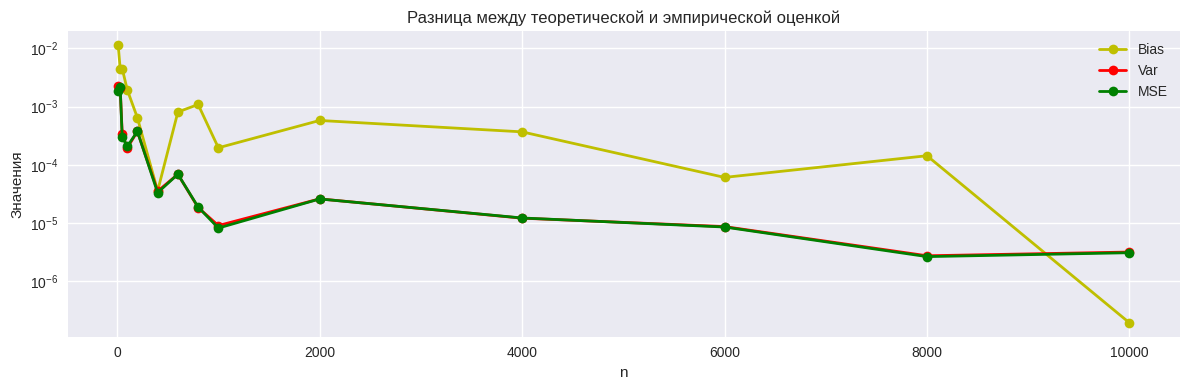

In [95]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

bias_diff = np.abs(df_emp_summary['bias'] - df_th_summary['bias'])
var_diff = np.abs(df_emp_summary['var'] - df_th_summary['var'])
mse_diff = np.abs(df_emp_summary['mse'] - df_th_summary['mse'])

ax.plot(df_emp_summary['n'], bias_diff, 'y-o', label='Bias', linewidth=2)
ax.plot(df_emp_summary['n'], var_diff, 'r-o', label='Var', linewidth=2)
ax.plot(df_emp_summary['n'], mse_diff, 'g-o', label='MSE', linewidth=2)

ax.set_xlabel('n')
ax.set_ylabel('Значения')
ax.set_title('Разница между теоретической и эмпирической оценкой')
ax.legend()
ax.grid(True)
ax.set_yscale('log')

plt.tight_layout()
plt.show()


## Визуализация: Распределение оценок

- ### Проанализируем распределение оценок для нескольких размеров выборки

$\qquad \hat{θ}_{\text{Bayes}} = \frac{1 + n\bar{X}}{1 + n} \xrightarrow{} N\left(θ, \frac{θ}{n}\right)$


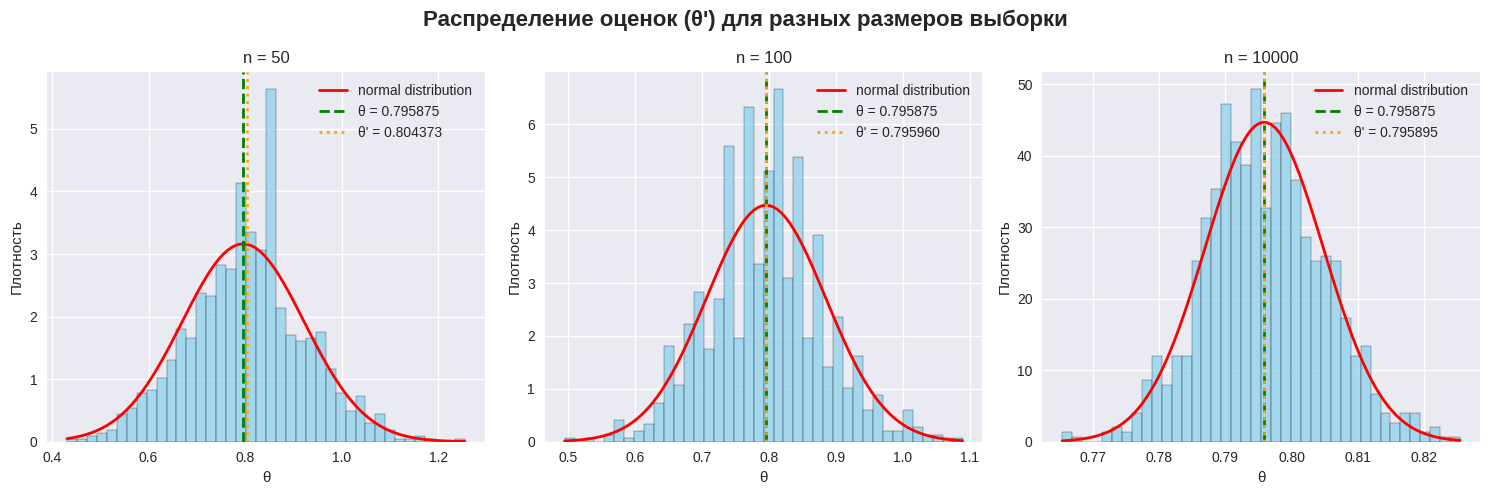

In [96]:
SIZES = [50, 100, 10000]

fig, axes = plt.subplots(1, len(SIZES), figsize=(15, 5))
fig.suptitle("Распределение оценок (θ') для разных размеров выборки", fontsize=16, fontweight='bold')

for i, n in enumerate(SIZES):
    estimates = ESTIMATIONS[n]
    axes[i].hist(estimates, bins=40, density=True, alpha=0.7, color='skyblue', edgecolor='black')

    # Теоретическое нормальное распределение
    x_range = np.linspace(estimates.min(), estimates.max(), 100)
    theoretical_pdf = stats.norm.pdf(x_range, THETA, np.sqrt(THETA / n))
    axes[i].plot(x_range, theoretical_pdf, 'r-', linewidth=2, label=f'normal distribution')

    # Истинное значение
    axes[i].axvline(x=THETA, color='green', linestyle='--', linewidth=2, label=f'θ = {THETA:.6f}')

    # Эмпирическое среднее
    emp_mean = EMP_DATA[SAMPLE_SIZES.index(n)]['mean']
    axes[i].axvline(x=emp_mean, color='orange', linestyle=':', linewidth=2, label=f"θ' = {emp_mean:.6f}")

    axes[i].set_title(f'n = {n}')
    axes[i].set_xlabel('θ')
    axes[i].set_ylabel('Плотность')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()


## Выводы и заключение

### Результаты эксперимента:

**1. Байесовская оценка смещена, но состоятельна**

- Смещение: $\text{Bias} = \frac{1-\theta}{1+n} \approx 0$

- Дисперсия: $\text{Var} = \frac{n\theta}{(1+n)^2} \approx \frac{\theta}{n}$

- $\text{MSE} \approx 0$

**2. Асимптотическая нормальность и эффективность**

- $\hat{\theta}_{\text{Bayes}} \xrightarrow{d} N\left(\theta, \frac{\theta}{n}\right)$

- Асимптотически эквивалентна оценке максимального правдоподобия

- Достигает границы Рао-Крамера в пределе

**3. Байесовские преимущества**

- Оптимальна относительно квадратичной функции потерь

- Использует априорную информацию для стабилизации оценок

- Естественная квантификация неопределенности

### Практические выводы:

- Байесовская оценка асимптотически эквивалентна MLE

- Экспериментально подтверждается теория байесовской статистики
